# 전처리

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv(r'C:\Users\컴퓨터\Documents\[부캠][basic] 심화프로젝트\2025_Airbnb_NYC_listings.csv') #----- 자기 경로 설정!!
df_cleaned = pd.read_csv(r'C:\Users\컴퓨터\Documents\data-analysis-project-BBB\data\first_clean_data.csv')

In [7]:
df['amenities']

0        ["Refrigerator", "Dishes and silverware", "Wif...
1        ["Oven", "Blender", "Luggage dropoff allowed",...
2        ["Portable fans", "Oven", "Baking sheet", "Fir...
3        ["Fire extinguisher", "Clothing storage: close...
4        ["Oven", "Rice maker", "Laundromat nearby", "L...
                               ...                        
22303    ["Air conditioning", "Carbon monoxide alarm", ...
22304    ["Air conditioning", "Carbon monoxide alarm", ...
22305    ["Air conditioning", "Carbon monoxide alarm", ...
22306    ["Oven", "Gym", "Blender", "Dedicated workspac...
22307    ["Air conditioning", "Carbon monoxide alarm", ...
Name: amenities, Length: 22308, dtype: str

# 데이터 전처리 (승근)
## 31 ~ 37번 칼럼 
#### ============================================================
#### 31 ~ 37 주요 컬럼 설명
#### ============================================================
#### • review_scores_location                           : 위치 평점
#### • review_scores_value                              : 가성비 평점
#### • calculated_host_listings_count                   : 호스트 숙소 수(계산값)
#### • calculated_host_listings_count_entire_homes      : 전체 숙소 수
#### • calculated_host_listings_count_private_rooms     : 개인실 수
#### • calculated_host_listings_count_shared_rooms      : 공유실 수
#### • reviews_per_month                                : 월 평균 리뷰 수

-----------------------

## 이번 프로젝트에 사용할 데이터프레임 만들기

In [8]:
cols = [
    'id','name','description','host_id','host_since','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','neighbourhood_cleansed',
    'neighbourhood_group_cleansed','latitude','longitude','property_type','room_type','accommodates','bedrooms','beds','amenities','price','availability_365',
    'number_of_reviews','number_of_reviews_ltm','estimated_occupancy_l365d','estimated_revenue_l365d','review_scores_rating','review_scores_accuracy','review_scores_cleanliness',
    'review_scores_checkin','review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]
df_sg = df[cols]

In [9]:
df_sg.shape

(22308, 37)

## 31번 컬럼 'review_scores_location'에 의한 전처리

In [10]:
df_sg_cleaned = df_sg.copy()

In [11]:
mask = (df_sg_cleaned['review_scores_location'].isna()) & (df_sg_cleaned['review_scores_accuracy'].notna())
df_sg_cleaned.loc[mask, 'review_scores_location'] = 5.0

In [12]:
df_sg_cleaned.loc[(df['review_scores_location'].isna()) & (df['review_scores_accuracy'].notna()),'review_scores_location']

10849    5.0
Name: review_scores_location, dtype: float64

In [13]:
df_sg_cleaned.shape

(22308, 37)

---------------

# 슈퍼 호스트 VS 일반 호스트 비교를 위한 전처리

In [14]:
df_sh = df_sg_cleaned

In [15]:
# 1번 전처리 결측값 unknown으로 대체
df_sh['description'] = df_sh['description'].fillna('unknown')

In [16]:
# 2번 컬럼 전처리 결측값 unknown으로 대체
df_sh['host_since'] = df_sh['host_since'].fillna('unknown')

In [17]:
# 3번 전처리 범주형 값들을 숫자형 4,3,2,1로 대체
mapping = {'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1}
df_sh['host_response_time'] = df_sh['host_response_time'].map(mapping)
# 3-1번 그러고 결측값들은 unknown으로 대체
df_sh['host_response_time'] = df_sh['host_response_time'].fillna(-1)

In [18]:
# 4번 전처리 일단은 %부분이 있어 문자열형이라 숫자형으로 바꿔줬음(내일 결측값 어떡해 할지 다시 상의 해봐야 할듯요 어렵네요...)보류
df_sh['host_response_rate'] = (df_sh['host_response_rate'].str.replace('%', '', regex=False).astype(float))

In [19]:
df_sh['host_response_rate']

0          NaN
1          NaN
2        100.0
3        100.0
4        100.0
         ...  
22303      NaN
22304    100.0
22305     94.0
22306     89.0
22307    100.0
Name: host_response_rate, Length: 22308, dtype: float64

In [20]:
# 일단 슈퍼호스트 값을 f/t를 숫자형 1,0으로 바꿔주고(매핑)
df_sh['host_is_superhost'] = df_sh['host_is_superhost'].map({'t':True, 'f':False})
# 전처리 마지막 슈퍼호스트 결측치 unknown대체 이거부터 결측값 채워야 rate컬럼 결측 슈퍼호스트랑 일반호스트 중앙값채워지면서 nan이 안됨
df_sh['host_is_superhost'] = df_sh['host_is_superhost'].fillna('unknown')
# 호스트 응답률 데이터 변환
df_sh['host_acceptance_rate'] = (df_sh['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float))

In [21]:
# host_is_superhost 기준으로 그룹을 나누고 각 그룹의 host_acceptance_rate 중앙값으로 결측값을 대체
# 슈퍼호스트와 일반호스트 그룹을 나누어 각 그룹의 중앙값으로 host_acceptance_rate 결측을 채움.
df_sh['host_acceptance_rate'] = (
    df_sh.groupby('host_is_superhost')['host_acceptance_rate']
       .transform(lambda x: x.fillna(x.median()))
)

In [22]:
# bedrooms 전처리
df_sh = df_sh.dropna(subset=["bedrooms"])

In [23]:
# beds 전처리
# 룸 타입별로 중앙값으로 beds 결측값 채우기
df_sh["beds"] = df_sh["beds"].fillna(df_sh.groupby("room_type")["beds"].transform("median"))
df_sh["beds"].value_counts()

beds
1.0     13019
2.0      5135
3.0      1896
4.0       911
0.0       634
5.0       328
6.0       180
7.0        66
8.0        54
9.0        17
10.0        7
12.0        4
13.0        3
11.0        2
42.0        1
14.0        1
21.0        1
Name: count, dtype: int64

In [24]:
# price "$", "," 제거 -> float형태로 변경
df_sh['price'] = (df_sh['price'].str.replace("$", "").str.replace(",","").astype(float))
df_sh['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
22303     72.0
22304     58.0
22305    299.0
22306    200.0
22307     58.0
Name: price, Length: 22259, dtype: float64

In [25]:
df_sh['log_price'] = np.log1p(df_sh['price'])

q1_log = np.percentile(df_sh['log_price'], 25)
q3_log = np.percentile(df_sh['log_price'], 75)
iqr_log = q3_log - q1_log

lower_log = q1_log - 1.5 * iqr_log
upper_log = q3_log + 1.5 * iqr_log

log_outliers = df_sh.loc[(df_sh['log_price'] > upper_log) | (df_sh['log_price'] < lower_log)]
print(f"로그 변환 후 이상치 개수: {len(log_outliers)}")

df_processed_log = df_sh.loc[df_sh['log_price'] > upper_log].copy()
df_processed_log.describe()

로그 변환 후 이상치 개수: 252


,id,host_id,host_response_time,host_response_rate,host_acceptance_rate,latitude,longitude,accommodates,bedrooms,beds,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
count,2.410000e+02,2.410000e+02,241.000000,176.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,...,93.000000,93.000000,93.000000,93.000000,241.000000,241.000000,241.000000,241.000000,93.000000,241.000000
mean,7.187696e+17,2.578366e+08,2.348548,95.670455,74.912863,40.743486,-73.972719,6.883817,2.365145,3.095436,...,4.909140,4.934409,4.869677,4.711290,72.273859,53.290456,3.170124,0.004149,0.418925,7.621052
std,4.687417e+17,2.094228e+08,2.141575,17.587477,28.458388,0.039462,0.039655,4.628151,2.113318,3.512362,...,0.175007,0.180395,0.206595,0.359372,202.127702,198.049191,10.164896,0.064416,0.657269,0.605080
min,1.749660e+05,4.972670e+05,-1.000000,0.000000,0.000000,40.576010,-74.098650,1.000000,0.000000,0.000000,...,4.000000,3.500000,4.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.020000,7.036148
25%,4.992023e+07,3.947710e+07,-1.000000,99.000000,58.000000,40.722780,-73.989240,3.000000,1.000000,1.000000,...,4.880000,4.940000,4.830000,4.600000,1.000000,1.000000,0.000000,0.000000,0.090000,7.195937
50%,8.306756e+17,3.082798e+08,4.000000,100.000000,87.000000,40.752656,-73.975831,6.000000,2.000000,2.000000,...,5.000000,5.000000,5.000000,4.810000,4.000000,2.000000,0.000000,0.000000,0.170000,7.443078
75%,1.111666e+18,4.655797e+08,4.000000,100.000000,89.000000,40.764694,-73.967018,10.000000,3.000000,4.000000,...,5.000000,5.000000,5.000000,5.000000,20.000000,7.000000,1.000000,0.000000,0.380000,7.824446
max,1.355509e+18,6.639210e+08,4.000000,100.000000,100.000000,40.898020,-73.726981,16.000000,15.000000,42.000000,...,5.000000,5.000000,5.000000,5.000000,1194.000000,1194.000000,45.000000,1.000000,3.170000,9.903538


In [26]:
# price 이상치 제거
target_index = log_outliers.index
df_sh.drop(target_index, axis = 0, inplace=True)

In [27]:
df_sh.shape

(22007, 38)

--------------------------------

# 슈퍼 호스트 VS 일반 호스트 분석을 위한 상관계수 구하기

In [28]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [ ]:
# 1. 25~50번째 컬럼 슬라이싱 + review_scores_rating 포함
target_columns = list(df_cleaned.columns) 
if 'review_scores_rating' not in target_columns:
    target_columns.append('review_scores_rating')

# 2. 그 중 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
review_scores_rating_corr = numeric_df.corr(method='spearman')['review_scores_rating'].sort_values(ascending=False)

print("--- 평점과 상관관계가 높은 주요 변수 ---")
print(review_scores_rating_corr)

--- 가격과 상관관계가 높은 주요 변수 ---
review_scores_rating                            1.000000
review_scores_accuracy                          0.778852
review_scores_value                             0.711800
review_scores_cleanliness                       0.707056
review_scores_communication                     0.691476
review_scores_checkin                           0.647184
review_scores_location                          0.473748
id                                              0.129799
Unnamed: 0                                      0.129747
log_price                                       0.100145
price                                           0.100145
host_response_rate                              0.069837
bedrooms                                        0.059570
estimated_revenue_l365d                         0.041775
estimated_occupancy_l365d                       0.010973
longitude                                       0.008880
host_response_time                              0.001071
calc

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

In [31]:
df_sh.info()

<class 'pandas.DataFrame'>
Index: 22007 entries, 0 to 22307
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22007 non-null  int64  
 1   name                                          22007 non-null  str    
 2   description                                   22007 non-null  str    
 3   host_id                                       22007 non-null  int64  
 4   host_since                                    22007 non-null  str    
 5   host_response_time                            22007 non-null  float64
 6   host_response_rate                            17683 non-null  float64
 7   host_acceptance_rate                          22007 non-null  float64
 8   host_is_superhost                             22007 non-null  object 
 9   neighbourhood_cleansed                        22007 non-null  str    
 10  ne

In [32]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22248 non-null  int64  
 1   id                                            22248 non-null  int64  
 2   name                                          22248 non-null  str    
 3   description                                   22248 non-null  str    
 4   host_id                                       22248 non-null  int64  
 5   host_since                                    22248 non-null  str    
 6   host_response_time                            22248 non-null  float64
 7   host_response_rate                            22248 non-null  float64
 8   host_acceptance_rate                          22248 non-null  float64
 9   host_is_superhost                             22248 non-null  str    
 1

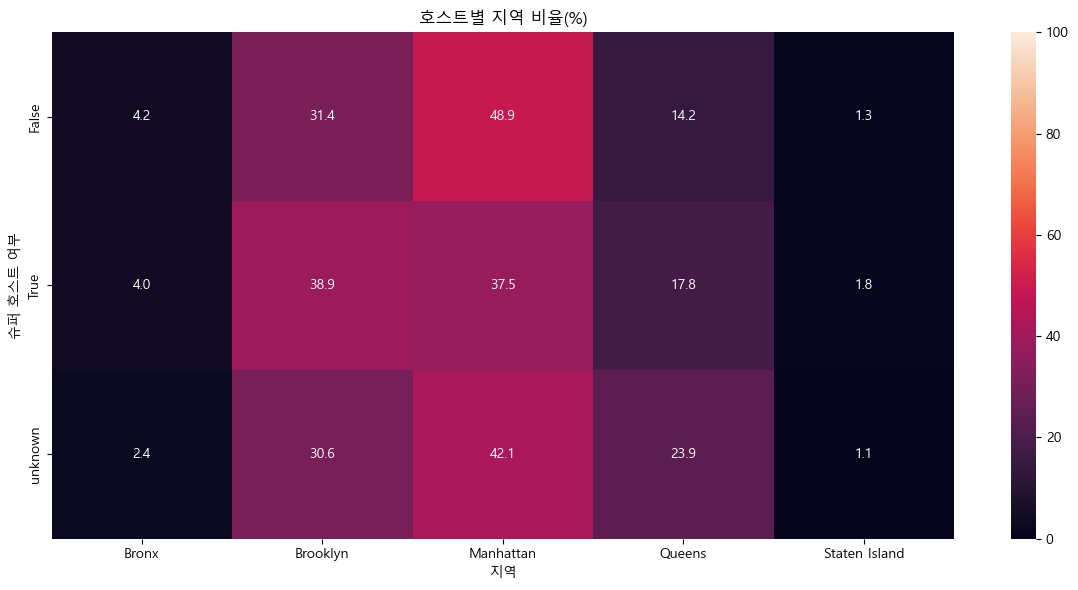

In [33]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct = pd.crosstab(df_cleaned["host_is_superhost"], df_cleaned["neighbourhood_group_cleansed"], normalize="index") * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("호스트별 지역 비율(%)")
plt.xlabel("지역")
plt.ylabel("슈퍼 호스트 여부")
plt.tight_layout()
plt.show()

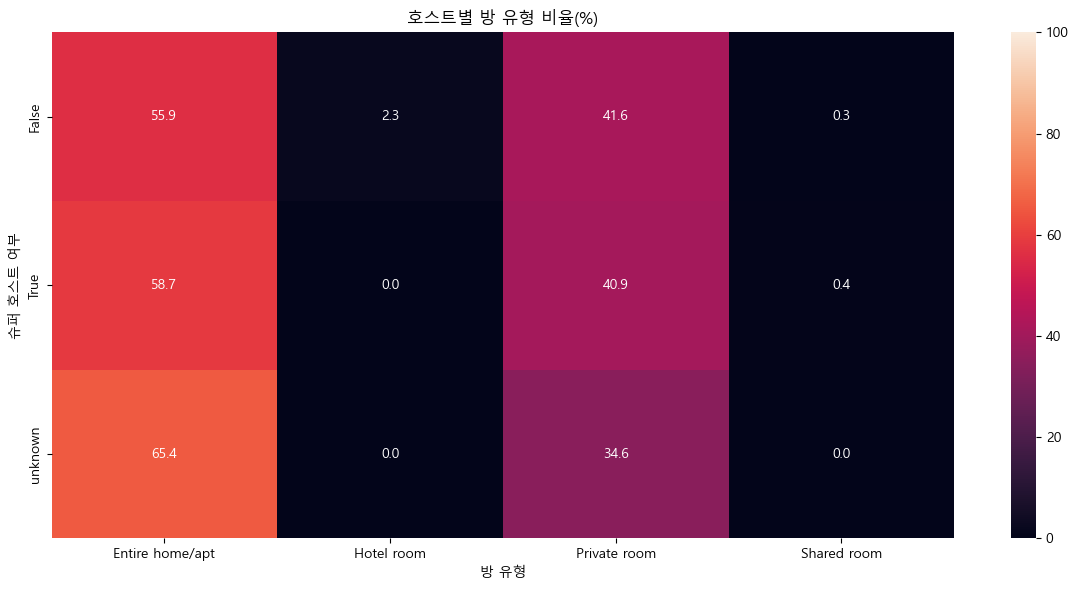

In [44]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct = pd.crosstab(df_cleaned["host_is_superhost"], df_cleaned["room_type"], normalize="index") * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("호스트별 방 유형 비율(%)")
plt.xlabel("방 유형")
plt.ylabel("슈퍼 호스트 여부")
plt.tight_layout()
plt.show()

----------------------------------

# 나만으 연습장 (볼 필요 X)

## TOP 10 amenities 출력

In [34]:
import ast
from collections import Counter

# 1. 문자열(String) 형태를 진짜 리스트(List)로 변환
# 데이터가 "['Wifi', 'Heating']" 처럼 따옴표까지 포함된 글자라면 이 과정이 꼭 필요!!
df['amenities'] = df['amenities'].apply(ast.literal_eval)

# 2. 리스트를 개별 행으로 펼치기 (Explode)
# 한 칸에 들어있던 [A, B, C]를 각각 3개의 행(A / B / C)으로 쪼개줍니다.
exploded_amenities = df['amenities'].explode()

# 3. 개수 세고 상위 10개 추출
top_10_amenities = exploded_amenities.value_counts().head(10)